# Conditional probability on a different dataset: Palmer penguins

*Part 1 · Lesson 5 · another dataset  ·  data: Palmer Penguins*

*↩ A companion to [Lesson 5: Probability & conditional probability](05-probability.ipynb).*

**↩ Back:** [Lesson 5: Probability & conditional probability](05-probability.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](05-probability~the-code.ipynb)

In the core lesson the Titanic taught us a dramatic truth: survival depended **strongly** on who you
were — your sex and your ticket class shifted the odds enormously. That left a tempting impression that
*conditioning always changes the answer.* It doesn't. Whether two facts are linked depends entirely on
**which two facts** you pick.

We'll count the same probabilities — marginal, joint, conditional — but on **333 Palmer penguins**, and
we'll meet **both extremes in one dataset**. For one pair of traits (a penguin's **sex** and its
**species**), conditioning changes almost nothing — they are essentially **independent**, the opposite
of the Titanic. For another pair (**species** and **island**), conditioning can make a species
*certain* or *impossible* — about as dependent as two things can get, and a perfect setting for a
**Bayes** flip. The lesson to carry away: don't assume — **test** independence by comparing the
conditional probability to the marginal.

Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()
rng = np.random.default_rng(12)  # fixed seed -> reproducible; learner can change it

PENGUINS_URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
pen = sl.load_csv('penguins.csv', url=PENGUINS_URL)
pen = pen.dropna(subset=['sex', 'species', 'island'])   # keep only fully-labeled penguins

print(f'{len(pen)} penguins with sex, species and island recorded')
print('species:', sorted(pen['species'].unique()))
print('islands:', sorted(pen['island'].unique()))
pen[['species', 'island', 'sex']].head()

333 penguins with sex, species and island recorded
species: ['Adelie', 'Chinstrap', 'Gentoo']
islands: ['Biscoe', 'Dream', 'Torgersen']


,species,island,sex
0,Adelie,Torgersen,male
1,Adelie,Torgersen,female
2,Adelie,Torgersen,female
4,Adelie,Torgersen,female
5,Adelie,Torgersen,male


## 1) Probability = favorable ÷ total (same as always)

A probability is still just bookkeeping: count the outcomes you care about and divide by the total. If I
reach into this list and pull one penguin out at random, **what's the chance it's female?**

$$P(\text{female}) = \frac{\text{number of females}}{\text{total number of penguins}}.$$

- **The math:** count the females, divide by 333.
- **The meaning:** a probability is a *fraction of a group* — a number between 0 (never) and 1 (always).
- **The interpretation:** a value near $0.5$ would say the colony is split roughly evenly by sex, so a
  blindly grabbed penguin is about as likely to be female as male.

A trick we'll reuse: make a True/False column (`sex == 'female'`) and take its **mean** — Python counts
`True` as 1, so the mean *is* the fraction.

In [2]:
n_total  = len(pen)
n_female = int((pen['sex'] == 'female').sum())
p_female = (pen['sex'] == 'female').mean()       # mean of True/False == the fraction

print(f"Females: {n_female} out of {n_total}")
print(f"P(female) = {n_female}/{n_total} = {p_female:.4f}")
print(f"So about {p_female*100:.0f}% of these penguins are female -- nearly a 50/50 split.")

Females: 165 out of 333
P(female) = 165/333 = 0.4955
So about 50% of these penguins are female -- nearly a 50/50 split.


## 2) Conditional probability — *restrict to a subgroup*

Now the sharper question: *given that a penguin is a **Gentoo**, what's the chance it's female?* That
"given" is **conditional probability**, written $P(A \mid B)$ and read "the probability of $A$ **given**
$B$."

- **The math:** two equivalent routes.
  1. *Restrict, then count:* throw away every penguin that isn't a Gentoo, then take the female fraction
     of who's left.
  2. *Divide two probabilities:* $\displaystyle P(A \mid B) = \frac{P(A \text{ and } B)}{P(B)}$.
- **The meaning:** the bar "$\mid B$" shrinks your world down to only the $B$ penguins. You stop asking
  about all 333 and ask only about the Gentoos.
- **The interpretation:** if $P(\text{female} \mid \text{Gentoo})$ comes out **different** from the
  overall $P(\text{female})$, then knowing the species *changes what you'd bet* about the sex. If it
  comes out **the same**, the species told you nothing.

Below we compute $P(\text{female} \mid \text{Gentoo})$ **both ways** and check they agree.

In [3]:
# Way 1 -- restrict to the subgroup, then take the female rate.
gentoo = pen[pen['species'] == 'Gentoo']
p_female_given_gentoo = (gentoo['sex'] == 'female').mean()

# Way 2 -- P(female AND Gentoo) / P(Gentoo), using the whole dataset.
p_gentoo            = (pen['species'] == 'Gentoo').mean()
p_female_and_gentoo = ((pen['species'] == 'Gentoo') & (pen['sex'] == 'female')).mean()
p_via_division      = p_female_and_gentoo / p_gentoo

print(f"P(female | Gentoo), restrict & count : {p_female_given_gentoo:.4f}")
print(f"P(female | Gentoo), joint / marginal : {p_via_division:.4f}   <- same number")
print()
print(f"P(female | Gentoo) = {p_female_given_gentoo:.4f}")
print(f"P(female) overall  = {p_female:.4f}")
print("These two numbers are nearly identical -- a big clue, which we chase down in section 4.")

P(female | Gentoo), restrict & count : 0.4874
P(female | Gentoo), joint / marginal : 0.4874   <- same number

P(female | Gentoo) = 0.4874
P(female) overall  = 0.4955
These two numbers are nearly identical -- a big clue, which we chase down in section 4.


**Read that out loud.** A Gentoo's chance of being female (~49%) is essentially the **overall** chance
of being female (~50%). Knowing the penguin is a Gentoo barely budged the bet. Compare that to the
Titanic, where learning a passenger was a woman shoved survival from 39% up to 74% — a huge swing. Same
machinery, completely different *strength* of effect. That contrast is the heart of this lesson.

## 3) The contingency table: marginal, joint & conditional in one grid

Every probability in this section lives inside one little table that cross-tabulates **species** against
**sex**. `pd.crosstab` builds it by counting.

In [4]:
counts = pd.crosstab(pen['species'], pen['sex'],
                     margins=True, margins_name='Total')
print("COUNTS -- how many penguins fall in each box:")
counts

COUNTS -- how many penguins fall in each box:


sex,female,male,Total
species,,,
Adelie,73,73,146
Chinstrap,34,34,68
Gentoo,58,61,119
Total,165,168,333


In [5]:
# Same table as PROPORTIONS of all 333 penguins (every box / grand total).
props = pd.crosstab(pen['species'], pen['sex'],
                    normalize=True, margins=True, margins_name='Total')
print("PROPORTIONS -- each box as a fraction of every penguin:")
props.round(4)

PROPORTIONS -- each box as a fraction of every penguin:


sex,female,male,Total
species,,,
Adelie,0.2192,0.2192,0.4384
Chinstrap,0.1021,0.1021,0.2042
Gentoo,0.1742,0.1832,0.3574
Total,0.4955,0.5045,1.0000


Three kinds of probability all live in that grid:

- **Marginal** — a probability in the *margin* (an edge total), ignoring the other variable. The bottom
  margin gives $P(\text{female}) \approx 0.495$; a right-hand margin would give each species' share.
- **Joint** — a probability in an *inner box*: two things true at once, e.g. $P(\text{female and
  Gentoo})$.
- **Conditional** — take an inner box and divide by a *row or column total*, which re-scales it to that
  subgroup: $P(\text{female} \mid \text{Gentoo}) = P(\text{female and Gentoo}) / P(\text{Gentoo})$.

This is the **multiplication rule**, just rearranged:

$$P(A \text{ and } B) = P(A \mid B)\, P(B).$$

- **Meaning:** to land in both $A$ *and* $B$, first land in $B$ (chance $P(B)$), then clear the narrower
  bet $A$-given-$B$ (chance $P(A\mid B)$). Multiply the two gates.
- **Interpretation:** joint, conditional, and marginal aren't three unrelated ideas — fix any two and
  the third is forced. Let's verify the rule by counting.

In [6]:
lhs = p_female_and_gentoo                    # P(female and Gentoo), counted directly
rhs = p_female_given_gentoo * p_gentoo       # P(female | Gentoo) * P(Gentoo)

print(f"P(female and Gentoo)             = {lhs:.4f}")
print(f"P(female | Gentoo) * P(Gentoo)   = {rhs:.4f}")
print(f"Match? {np.isclose(lhs, rhs)}   <- the multiplication rule, confirmed by counting.")

P(female and Gentoo)             = 0.1742
P(female | Gentoo) * P(Gentoo)   = 0.1742
Match? True   <- the multiplication rule, confirmed by counting.


## 4) Independence — when knowing the species tells you *nothing about sex*

Two events are **independent** if conditioning on one doesn't move the other:

$$P(A \mid B) = P(A) \quad\Longleftrightarrow\quad P(A \text{ and } B) = P(A)\,P(B).$$

- **The math:** compare the conditional to the marginal. If $P(A\mid B) = P(A)$, they're independent.
- **The meaning:** "independent" = *no information leaks* between the two. Learning $B$ leaves your bet
  on $A$ exactly where it was.
- **The interpretation — how to *test* it:** line up $P(\text{female}\mid\text{species})$ for **every**
  species against the overall $P(\text{female})$. If they all land on top of it, sex and species carry
  no information about each other.

We already saw $P(\text{female}\mid\text{Gentoo}) \approx P(\text{female})$. Let's check Adelie and
Chinstrap too, and read the verdict off a chart.

In [7]:
# Test independence: P(female | each species) vs the overall P(female).
female_by_species = pen.groupby('species', observed=True).apply(
    lambda g: (g['sex'] == 'female').mean())
species_order = ['Adelie', 'Chinstrap', 'Gentoo']
female_by_species = female_by_species.reindex(species_order)

for sp, r in female_by_species.items():
    gap = r - p_female
    print(f"P(female | {sp:<9}) = {r:.4f}   (overall {p_female:.4f}, gap {gap:+.4f})")
print()
print("Every conditional sits right on the overall rate -> sex and species are ESSENTIALLY INDEPENDENT.")
print("Knowing the species tells you almost nothing about the chance of female.")

P(female | Adelie   ) = 0.5000   (overall 0.4955, gap +0.0045)
P(female | Chinstrap) = 0.5000   (overall 0.4955, gap +0.0045)
P(female | Gentoo   ) = 0.4874   (overall 0.4955, gap -0.0081)

Every conditional sits right on the overall rate -> sex and species are ESSENTIALLY INDEPENDENT.
Knowing the species tells you almost nothing about the chance of female.


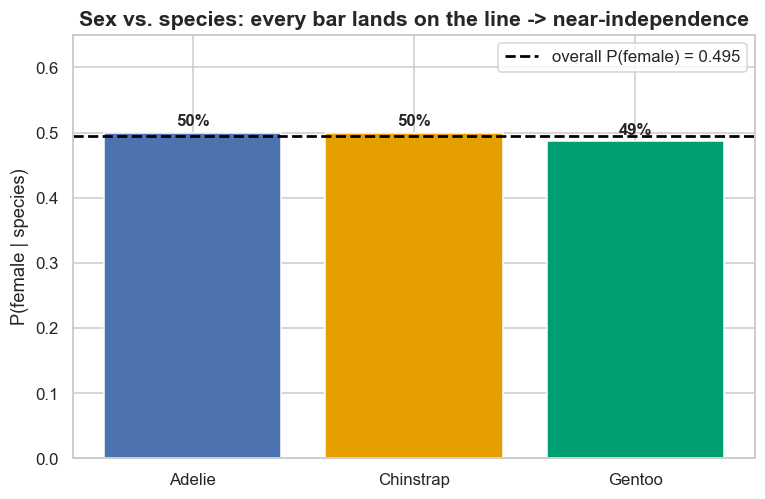

In [8]:
# Picture it: bars = P(female | species), dashed line = overall P(female).
fig, ax = plt.subplots()
bars = ax.bar(species_order, female_by_species.values,
              color=['#4c72b0', '#E69F00', '#009E73'], edgecolor='white')
ax.axhline(p_female, color='black', ls='--', lw=1.8,
           label=f'overall P(female) = {p_female:.3f}')
for b, r in zip(bars, female_by_species.values):
    ax.text(b.get_x() + b.get_width()/2, r + 0.01, f'{r:.0%}', ha='center', fontweight='bold')
ax.set_ylabel('P(female | species)'); ax.set_ylim(0, 0.65)
ax.set_title('Sex vs. species: every bar lands on the line -> near-independence')
ax.legend(); plt.show()

**Interpretation.** All three bars hug the dashed line. That flatness *is* what independence looks like
— conditioning on species moves the female rate by at most a percentage point or two (just sampling
wiggle from a finite colony). Contrast the Titanic survival-by-class chart in the core lesson, where the
bars towered above and plunged below the overall line. **Same picture, opposite story:** there the
condition mattered enormously; here it barely registers. Independence isn't rare or guaranteed — it's a
property of the *specific pair* of variables, and you find out by comparing the conditional to the
marginal.

## 5) The other extreme — species & island are *wildly* dependent

Now swap one variable. Instead of sex, cross species against the **island** each penguin lives on. The
counting is identical; the story flips completely.

In [9]:
island_table = pd.crosstab(pen['species'], pen['island'])
print("COUNTS -- penguins of each species found on each island:")
print(island_table)
print()
print("Look at the zeros: Chinstrap lives ONLY on Dream; Gentoo ONLY on Biscoe; Adelie on all three.")

COUNTS -- penguins of each species found on each island:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     55         47
Chinstrap       0     68          0
Gentoo        119      0          0

Look at the zeros: Chinstrap lives ONLY on Dream; Gentoo ONLY on Biscoe; Adelie on all three.


In [10]:
# P(species | island): restrict to one island, then take each species' share.
p_species_given_island = pd.crosstab(pen['island'], pen['species'], normalize='index')
print("P(species | island) -- each ROW conditions on a single island and sums to 1:")
print(p_species_given_island.round(3))
print()
p_species = pen['species'].value_counts(normalize=True).reindex(species_order)
print("Compare to the OVERALL P(species) (ignoring island):")
for sp, r in p_species.items():
    print(f"  P({sp:<9}) = {r:.3f}")

P(species | island) -- each ROW conditions on a single island and sums to 1:
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe      0.270      0.000    0.73
Dream       0.447      0.553    0.00
Torgersen   1.000      0.000    0.00

Compare to the OVERALL P(species) (ignoring island):
  P(Adelie   ) = 0.438
  P(Chinstrap) = 0.204
  P(Gentoo   ) = 0.357


These conditional rows are nothing like the overall shares. Knowing the island can drive a species'
probability all the way to **0** (impossible) or **1** (certain):

- On **Dream**, $P(\text{Gentoo}\mid\text{Dream}) = 0$ — there are simply no Gentoos there.
- On **Biscoe**, the only species besides Adelie is Gentoo, so $P(\text{Gentoo}\mid\text{Biscoe})$ is
  large; on **Torgersen** every single penguin is an Adelie, so $P(\text{Adelie}\mid\text{Torgersen}) = 1$.

That is **strong dependence**: $P(\text{species}\mid\text{island})$ is dramatically different from
$P(\text{species})$. This is the Titanic-style story — like survival-and-sex — except even more extreme,
because here the condition can make an outcome *certain* or *impossible*, not merely more or less likely.

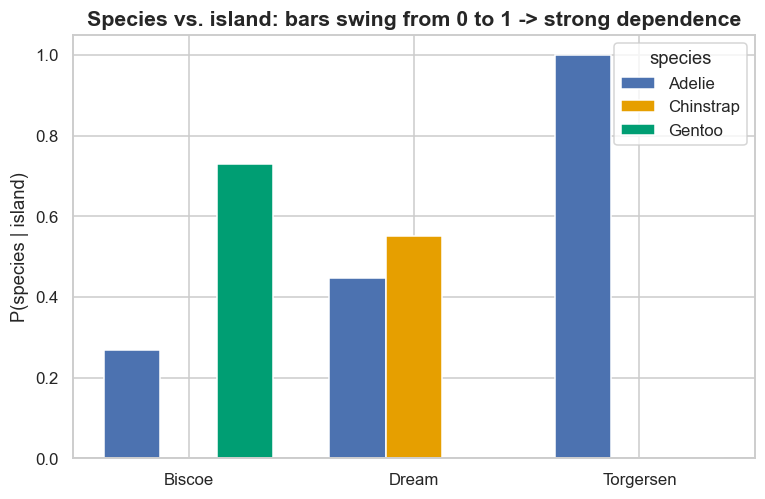

In [11]:
# Picture the dependence: grouped bars of P(species | island) per island.
fig, ax = plt.subplots()
islands = list(p_species_given_island.index)
x = np.arange(len(islands)); w = 0.25
colors = {'Adelie': '#4c72b0', 'Chinstrap': '#E69F00', 'Gentoo': '#009E73'}
for k, sp in enumerate(species_order):
    vals = p_species_given_island[sp].values
    ax.bar(x + (k - 1) * w, vals, w, label=sp, color=colors[sp], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(islands)
ax.set_ylabel('P(species | island)'); ax.set_ylim(0, 1.05)
ax.set_title('Species vs. island: bars swing from 0 to 1 -> strong dependence')
ax.legend(title='species'); plt.show()

**Interpretation.** Where the sex chart was three bars on one flat line, this chart is all spikes and
gaps: some bars vanish to zero, others shoot to one. *Same dataset, same counting* — the only thing that
changed is **which pair of variables** we crossed. That is the whole point: independence is not a global
fact about penguins (or about people), it's a fact about a *specific pair*. One pair here is essentially
independent; another is about as dependent as variables get.

## 6) A first taste of Bayes — flipping the conditional

The island/species link is so clean it makes a perfect **Bayes** example. Start with a forward question
we can read off the table: **given a penguin is on Biscoe, how likely is it a Gentoo?**

$$P(\text{Gentoo}\mid\text{Biscoe}) = \frac{\text{Gentoos on Biscoe}}{\text{all penguins on Biscoe}}.$$

Now flip it to the *backward* question: **given a penguin is a Gentoo, how likely is it on Biscoe?**
These are different questions, and in general

$$P(A \mid B) \ne P(B \mid A).$$

**Bayes' theorem** is the exact recipe for turning one around into the other:

$$P(\text{Biscoe}\mid\text{Gentoo}) = \frac{P(\text{Gentoo}\mid\text{Biscoe})\; P(\text{Biscoe})}{P(\text{Gentoo})}.$$

- **The math:** multiply the conditional you *have* by the marginal of its condition, then divide by the
  marginal of the thing you conditioned *on*.
- **The meaning:** it re-weights the forward probability by how common Biscoe is and how common Gentoos
  are overall.
- **The interpretation:** the backward answer is a genuinely different fact about the world than the
  forward one — here, spectacularly so.

Let's compute the flip from the three ingredients, then check it against the table directly.

In [12]:
# Forward: P(Gentoo | Biscoe), straight from the table.
biscoe = pen[pen['island'] == 'Biscoe']
p_gentoo_given_biscoe = (biscoe['species'] == 'Gentoo').mean()

# Bayes flip: P(Biscoe | Gentoo) from the three ingredients.
p_biscoe = (pen['island'] == 'Biscoe').mean()
p_biscoe_given_gentoo_bayes = (p_gentoo_given_biscoe * p_biscoe) / p_gentoo

# Direct check: among Gentoos only, what fraction live on Biscoe?
p_biscoe_given_gentoo_direct = (gentoo['island'] == 'Biscoe').mean()

print(f"P(Gentoo | Biscoe)                 = {p_gentoo_given_biscoe:.4f}   (forward)")
print(f"P(Biscoe | Gentoo) via Bayes       = {p_biscoe_given_gentoo_bayes:.4f}")
print(f"P(Biscoe | Gentoo) from counting   = {p_biscoe_given_gentoo_direct:.4f}   <- matches Bayes")
print()
print(f"Punchline:  P(Gentoo | Biscoe) = {p_gentoo_given_biscoe:.2f}, "
      f"but  P(Biscoe | Gentoo) = {p_biscoe_given_gentoo_direct:.2f}.")
print("Same two facts, opposite condition, DIFFERENT numbers. Order matters!")

P(Gentoo | Biscoe)                 = 0.7301   (forward)
P(Biscoe | Gentoo) via Bayes       = 1.0000
P(Biscoe | Gentoo) from counting   = 1.0000   <- matches Bayes

Punchline:  P(Gentoo | Biscoe) = 0.73, but  P(Biscoe | Gentoo) = 1.00.
Same two facts, opposite condition, DIFFERENT numbers. Order matters!


Why so different? Because the two questions are weighted by different **base rates** (how common each
group is to begin with). Being on Biscoe makes you *probably* a Gentoo — but Biscoe also houses plenty
of Adelies, so the forward probability is well under 1. Being a Gentoo, on the other hand, makes Biscoe a
**certainty**: every Gentoo in the data lives there, so $P(\text{Biscoe}\mid\text{Gentoo}) = 1$. Bayes is
just the machinery that respects those base rates when you flip the question — we build a whole lesson on
it later.

## Now you try

Predict the answer first, then change one thing and re-run:

1. **Pick a different "independence" check.** In section 4, the test was sex-vs-species. Add a new cell
   (the **+** button) and compute `P(female | island)` for each island the same way (group by `'island'`
   instead of `'species'`). Is sex independent of *island* too, or does one island skew male/female?
   Compare each value to the overall `p_female`.

2. **Flip a different Bayes pair.** In section 6 we flipped Biscoe↔Gentoo. Try **Dream** and
   **Chinstrap** instead: compute `P(Chinstrap | Dream)` and then `P(Dream | Chinstrap)`. One of them is
   exactly 1 — predict *which* before you run it, using the zeros in the island table.

3. **Make a strong dependence look weak (a trap).** In section 2 we conditioned sex on species and found
   near-independence. Now condition **species** on **sex**: compute `P(Gentoo | female)` and
   `P(Gentoo | male)`. Because sex and species are independent, these should both land near the overall
   `P(Gentoo)` — confirm it, and note that independence works *both directions*.

4. **Break the near-independence on purpose.** Drop the Gentoos (`pen[pen['species'] != 'Gentoo']`) and
   redo the section-4 check on the two remaining species. Adelie and Chinstrap are each split 50/50 by
   sex, so the bars should still be flat — independence survives subsetting here.

## What you learned

- **Probability is favorable ÷ total** — a fraction of a group between 0 and 1. For a True/False column
  it's just the `.mean()`.
- **Conditional probability $P(A\mid B)$** shrinks the world to the subgroup $B$; compute it by
  restricting-and-counting *or* as $P(A\text{ and }B)/P(B)$ — same answer.
- A **contingency table** (`pd.crosstab`) holds **marginal** (edge), **joint** (inner box), and
  **conditional** (box ÷ margin) probabilities, tied together by the **multiplication rule**
  $P(A\text{ and }B)=P(A\mid B)\,P(B)$.
- **Independence means conditioning changes nothing** ($P(A\mid B)=P(A)$). You **test** it by comparing
  the conditional to the marginal: sex and species are **essentially independent** (every
  $P(\text{female}\mid\text{species}) \approx P(\text{female}) \approx 0.50$), while species and island
  are **wildly dependent** ($P(\text{species}\mid\text{island})$ swings all the way from 0 to 1).
- Independence is a property of the **specific pair** of variables — not rare, not guaranteed. The
  Titanic's survival depended *strongly* on sex and class; here one penguin pair is independent and
  another is extreme — in the very same dataset.
- **Bayes flips a conditional:** $P(A\mid B)\ne P(B\mid A)$ in general. We turned
  $P(\text{Gentoo}\mid\text{Biscoe})$ into $P(\text{Biscoe}\mid\text{Gentoo}) = 1$ using the base rates.

---

**↩ Back to the lesson:** [Lesson 5: Probability & conditional probability](05-probability.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](05-probability~the-code.ipynb)